In [ ]:
!pip -q install imbalanced-learn

In [30]:
#Montar el Drive Personal solo para obtener el ipynb
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
#Clonar el repositorio de GitHub del proyecto sólo una vez
!git clone https://github.com/cluis0/ALURA-CHALLENGE-TELECOMX2.git

Cloning into 'ALURA-CHALLENGE-TELECOMX2'...


In [33]:
%cd ALURA-CHALLENGE-TELECOMX2
!ls

/content/ALURA-CHALLENGE-TELECOMX2


In [34]:
#Copiar el .ipynb al repositorio clonado de GitHub
!cp "/content/drive/MyDrive/Colab Notebooks/TelecomX_LATAM2.ipynb" "/content/ALURA-CHALLENGE-TELECOMX/TelecomX_LATAM2.ipynb"

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/TelecomX_LATAM2.ipynb': No such file or directory


#Extracción del Archivo Tratado

<a name="extraccion-del-archivo-tratado"></a>
###Extracción del Archivo Tratado

In [2]:
#Extracción del Archivo Tratado
import pandas as pd

path = "/content/TelecomX_LATAM.csv"
df = pd.read_csv(path)

# 4) Verificación rápida (Sanity check)
print("Shape (filas, columnas):", df.shape)

Shape (filas, columnas): (7267, 40)


In [3]:
#Revisar los primeros registros del DF
print("\n\33[1mRevisar los primeros registros del DF\33[0m\n")
print(df.head())
#Revisar la estructura del DF
print("\n\33[1mRevisar la estructura del DF\33[0m\n")
print(df.info())
#Revisar la estructura del DF
print("\n\33[1mRevisar las estadísticas básicas del DF\33[0m\n")
print(df.describe())


Revisar los primeros registros del DF

   customerID  Churn  customer.gender  customer.SeniorCitizen  \
0  0002-ORFBO      0                0                       0   
1  0003-MKNFE      0                1                       0   
2  0004-TLHLJ      1                1                       0   
3  0011-IGKFF      1                1                       1   
4  0013-EXCHZ      1                0                       1   

   customer.Partner  customer.Dependents  customer.tenure  phone.PhoneService  \
0                 1                    1                9                   1   
1                 0                    0                9                   1   
2                 0                    0                4                   1   
3                 1                    0               13                   1   
4                 1                    0                3                   1   

   account.PaperlessBilling account.PaymentMethod  ...  \
0                       

#Eliminación de Columnas Irrelevantes

###La eliminación de columnas redundantes da paso a eliminar la variable CustomerID que es un sólo un identificador del cliente (alta cardinalidad, no contiene señal causal/predictiva generalizable). Si esta vaiable se queda, puede meter ruido o fugas indirectas en el análisis.
###La segunda variable que se propone a eliminar es account.Charges.Daily (fue introducida como parte de los entegables del Challenge pasado pero que no aporta gran información porque puede ser derivada) ya que normalmente es una transformación directa de account.Charges.Monthly (p.ej., Monthly/30).

*   Mantener ambas añade **redundancia/multicolinealidad** (especialmente para modelos lineales) sin aportar información nueva.
*   Para modelos tipo árboles no “rompe” nada, pero sigue siendo redundante.



<a name="eliminacion-columnas-irrelevantes"></a>
###Eliminación de columnas irrelevantes

In [4]:
# Paso 2: eliminar columnas irrelevantes / redundantes con justificación

cols_to_drop = []

# 1) ID del cliente (irrelevante para modelado)
if "customerID" in df.columns:
    cols_to_drop.append("customerID")

# 2) Columna derivada (redundante) - opcional pero recomendado
if "account.Charges.Daily" in df.columns:
    cols_to_drop.append("account.Charges.Daily")

print("Columnas a eliminar:", cols_to_drop)

df = df.drop(columns=cols_to_drop, errors="ignore")

print("Nuevo shape:", df.shape)
display(df.head())

Columnas a eliminar: ['customerID', 'account.Charges.Daily']
Nuevo shape: (7267, 38)


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,...,internet.TechSupport_Yes,internet.StreamingTV_No,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year
0,0,0,0,1,1,9,1,1,Mailed check,65.6,...,1,0,0,1,1,0,0,0,1,0
1,0,1,0,0,0,9,1,0,Mailed check,59.9,...,0,1,0,0,0,0,1,1,0,0
2,1,1,0,0,0,4,1,1,Electronic check,73.9,...,0,1,0,0,1,0,0,1,0,0
3,1,1,1,1,0,13,1,1,Electronic check,98.0,...,0,0,0,1,0,0,1,1,0,0
4,1,0,1,1,0,3,1,1,Mailed check,83.9,...,1,0,0,1,1,0,0,1,0,0


#Encoding

###En la primera parte del Challenge, opté por usar una regla respecto a las variables categóricas y su uso en el OHE; aquí la reproduzco:

*   Variable binaria: Valores 0 y 1
*   Variable ternaria: Variable convertida a OHE. Valores 0 y 1
*   Variable n-aria (n > 3): Valores quedan igual

###Sin embargo, ahora propongo convertir a OHE la única columna candidata para eso y dejar todo el dataframe listo para usar Machine Learning. La variable es account.PaymentMethod.







In [5]:
# Paso 3: One-Hot Encoding de columnas categóricas restantes

df = pd.get_dummies(
    df,
    columns=["account.PaymentMethod"],
    drop_first=True
)

print("Nuevo shape del dataset:", df.shape)


Nuevo shape del dataset: (7267, 40)


In [6]:
# Convertir columnas booleanas (True/False) a numéricas (0/1)

import numpy as np

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(np.int8)

print("Columnas booleanas convertidas:", list(bool_cols))
print(df[bool_cols].dtypes.value_counts())

Columnas booleanas convertidas: ['account.PaymentMethod_Credit card (automatic)', 'account.PaymentMethod_Electronic check', 'account.PaymentMethod_Mailed check']
int8    3
Name: count, dtype: int64


#Verificación de la Proporción de Cancelación (Churn)

<a name="verificacion-de-la-proporcion-de-cancelacion"></a>
###Verificación de la Proporción de Cancelación (Churn)

In [7]:
#Obtención del porcentaje de deserción de clientes
#Este es el punto base de análisis de 'Churn'

df['Churn'].value_counts(normalize=True)


,proportion
Churn,
0,0.74281
1,0.25719


,conteo,porcentaje
Churn,,
0,5398,74.28
1,1869,25.72


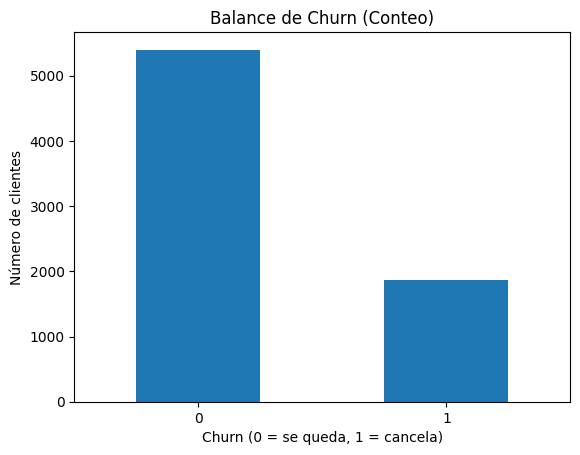

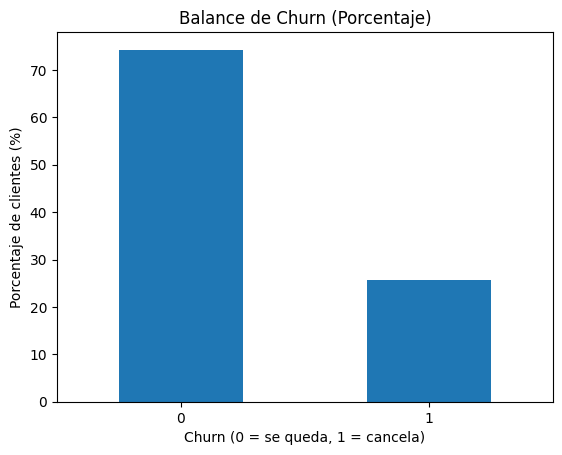

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Conteo y porcentajes
churn_counts = df["Churn"].value_counts().sort_index()          # 0, 1
churn_pct = df["Churn"].value_counts(normalize=True).sort_index() * 100

# Mostrar tabla resumen
balance_df = pd.DataFrame({
    "conteo": churn_counts,
    "porcentaje": churn_pct.round(2)
})
display(balance_df)

# Gráfica: conteo
plt.figure()
churn_counts.plot(kind="bar")
plt.title("Balance de Churn (Conteo)")
plt.xlabel("Churn (0 = se queda, 1 = cancela)")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.show()

# Gráfica: porcentaje
plt.figure()
churn_pct.plot(kind="bar")
plt.title("Balance de Churn (Porcentaje)")
plt.xlabel("Churn (0 = se queda, 1 = cancela)")
plt.ylabel("Porcentaje de clientes (%)")
plt.xticks(rotation=0)
plt.show()

#Balanceo de Clases (opcional)

#Normalización o Estandarización

#Separación de Datos

<a name="balanceo-de-Clases"></a>
###Balanceo de Clases (opcional)

<a name="normalización-o-estandarizacion"></a>
###Normalización o Estandarización

<a name="separacion-de-datos"></a>
###Separación de Datos

In [9]:
from sklearn.model_selection import train_test_split

# 1) Separar features y target
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)  # por si quedó como bool o float

# 2) Split estratificado (mantiene proporción de Churn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nDistribución en TRAIN:\n", y_train.value_counts(normalize=True).round(4))
print("\nDistribución en TEST:\n", y_test.value_counts(normalize=True).round(4))

Train: (5813, 39)  Test: (1454, 39)

Distribución en TRAIN:
 Churn
0    0.7428
1    0.2572
Name: proportion, dtype: float64

Distribución en TEST:
 Churn
0    0.7428
1    0.2572
Name: proportion, dtype: float64


<a name="baseline-reproducible-sin-balanceo"></a>
###Baseline reproducible (línea base) para predecir Churn (sin balanceo)

=== Classification report (TEST) ===
              precision    recall  f1-score   support

           0     0.8477    0.8917    0.8691      1080
           1     0.6321    0.5374    0.5809       374

    accuracy                         0.8006      1454
   macro avg     0.7399    0.7145    0.7250      1454
weighted avg     0.7922    0.8006    0.7950      1454

ROC-AUC: 0.8439
PR-AUC (Average Precision): 0.6239


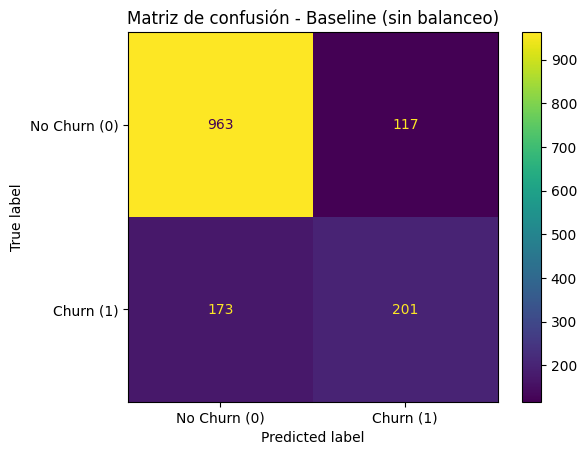

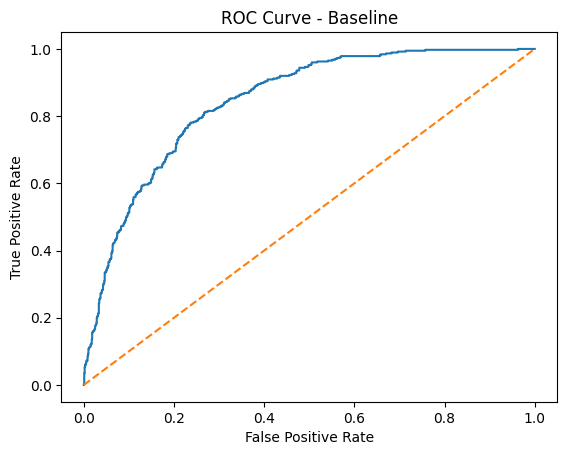

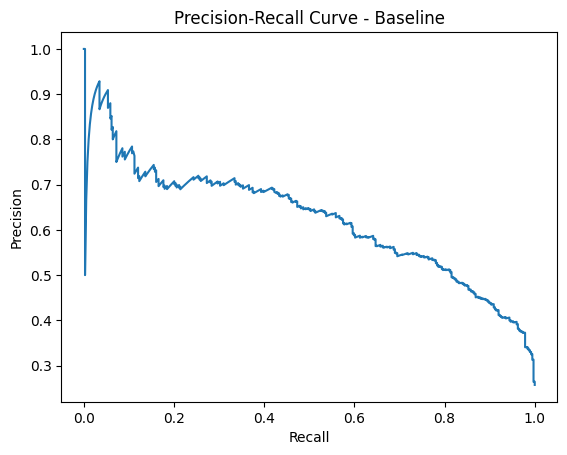

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------- 2) Preprocesamiento robusto (por tipo de dato) ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns  # object/category/bool si quedara

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # compatible con matrices sparse si hay OHE
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Modelo baseline (SIN balanceo) ----------
baseline_clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", baseline_clf)
])

baseline_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) ===")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Baseline (sin balanceo)")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline")
plt.show()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline")
plt.show()

<a name="baseline-reproducible-con-balanceo"></a>
###Baseline reproducible (línea base) para predecir Churn (con balanceo)

=== Classification report (TEST) - class_weight='balanced' ===
              precision    recall  f1-score   support

           0     0.9165    0.7213    0.8073      1080
           1     0.5017    0.8102    0.6196       374

    accuracy                         0.7442      1454
   macro avg     0.7091    0.7657    0.7134      1454
weighted avg     0.8098    0.7442    0.7590      1454

ROC-AUC: 0.8438
PR-AUC (Average Precision): 0.6214


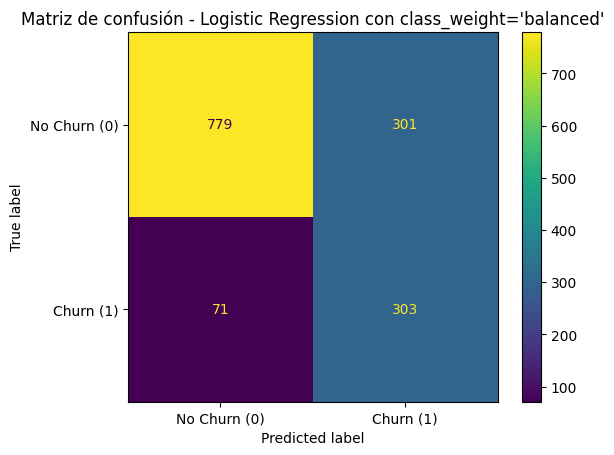

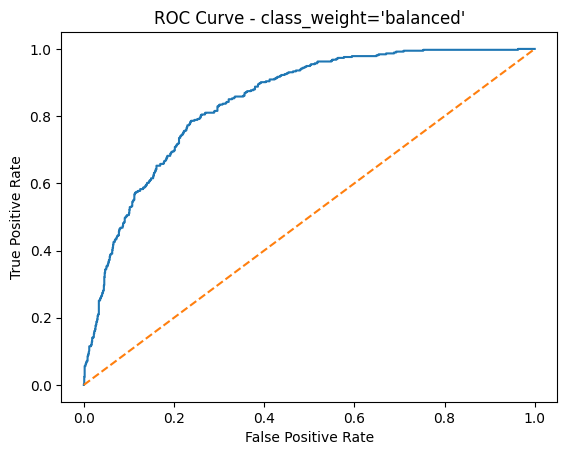

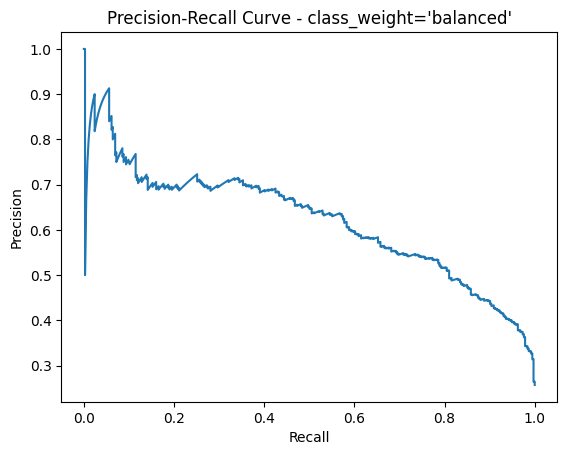

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------- 2) Preprocesamiento robusto (por tipo de dato) ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Modelo con class_weight="balanced" ----------
balanced_clf = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs"
)

balanced_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", balanced_clf)
])

balanced_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred_bal = balanced_model.predict(X_test)
y_proba_bal = balanced_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, digits=4))

roc_auc_bal = roc_auc_score(y_test, y_proba_bal)
pr_auc_bal = average_precision_score(y_test, y_proba_bal)

print(f"ROC-AUC: {roc_auc_bal:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_bal:.4f}")

# Matriz de confusión
cm_bal = confusion_matrix(y_test, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Logistic Regression con class_weight='balanced'")
plt.show()

# Curva ROC
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_proba_bal)
plt.figure()
plt.plot(fpr_bal, tpr_bal)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - class_weight='balanced'")
plt.show()

# Curva Precision-Recall
precision_bal, recall_bal, _ = precision_recall_curve(y_test, y_proba_bal)
plt.figure()
plt.plot(recall_bal, precision_bal)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - class_weight='balanced'")
plt.show()

<a name="baseline-reproducible-con-smote"></a>
###Baseline reproducible (línea base) para predecir Churn (con SMOTE)

=== Classification report (TEST) - SMOTE ===
              precision    recall  f1-score   support

           0     0.9166    0.7426    0.8205      1080
           1     0.5199    0.8048    0.6317       374

    accuracy                         0.7586      1454
   macro avg     0.7182    0.7737    0.7261      1454
weighted avg     0.8145    0.7586    0.7719      1454

ROC-AUC: 0.8432
PR-AUC (Average Precision): 0.6250


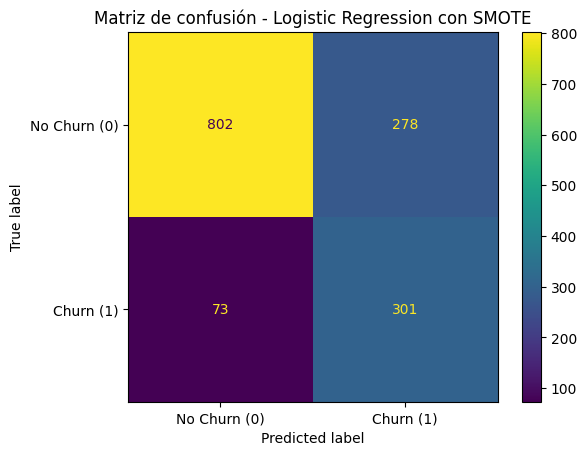

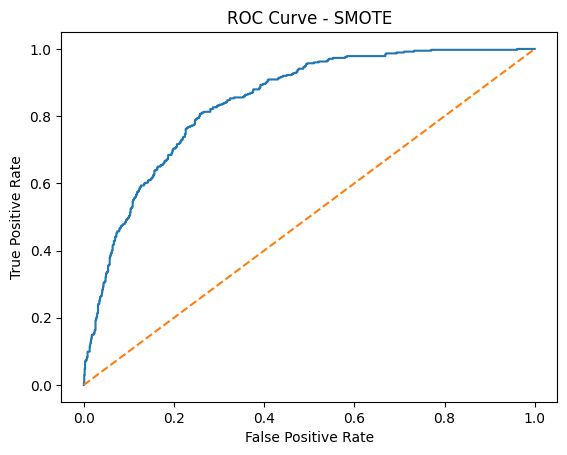

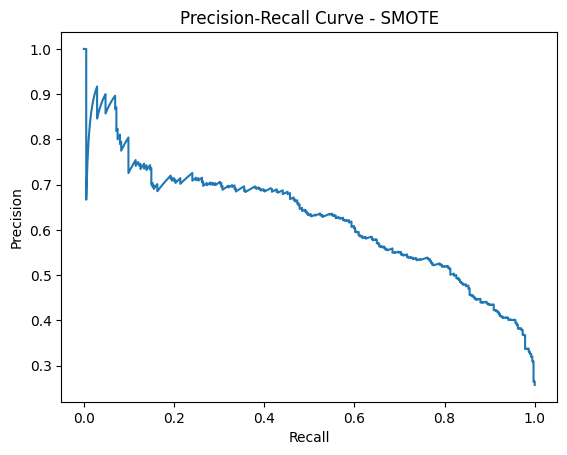

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------- 2) Preprocesamiento (igual que antes) ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) SMOTE + Modelo ----------
smote = SMOTE(random_state=42, k_neighbors=5)

clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

smote_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", smote),
    ("clf", clf)
])

smote_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred = smote_model.predict(X_test)
y_proba = smote_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - SMOTE ===")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Logistic Regression con SMOTE")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE")
plt.show()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SMOTE")
plt.show()

<a name="balanceo-de-modelos-todos"></a>
###Resultados del balanceo de modelos (baseline VS balanced VS SMOTE)

In [13]:
import pandas as pd

results = pd.DataFrame([
    {
        "Modelo": "Baseline",
        "TP": 201, "FP": 117, "FN": 173, "TN": 963,
        "Recall(1)": 0.5374, "Precision(1)": 0.6321, "F1(1)": 0.5809,
        "ROC-AUC": 0.8439, "PR-AUC": 0.6239, "Accuracy": 0.8006
    },
    {
        "Modelo": "Class_weight=balanced",
        "TP": 303, "FP": 301, "FN": 71, "TN": 779,
        "Recall(1)": 0.8102, "Precision(1)": 0.5017, "F1(1)": 0.6196,
        "ROC-AUC": 0.8438, "PR-AUC": 0.6214, "Accuracy": 0.7442
    },
    {
        "Modelo": "SMOTE",
        "TP": 301, "FP": 278, "FN": 73, "TN": 802,
        "Recall(1)": 0.8048, "Precision(1)": 0.5199, "F1(1)": 0.6317,
        "ROC-AUC": 0.8432, "PR-AUC": 0.6250, "Accuracy": 0.7586
    }
])

#Se despliegan los resultados de las métricas y se ordena por equilibrio operativo (F1(1))
display(results.sort_values("F1(1)", ascending=False))

,Modelo,TP,FP,FN,TN,Recall(1),Precision(1),F1(1),ROC-AUC,PR-AUC,Accuracy
2,SMOTE,301,278,73,802,0.8048,0.5199,0.6317,0.8432,0.6250,0.7586
1,Class_weight=balanced,303,301,71,779,0.8102,0.5017,0.6196,0.8438,0.6214,0.7442
0,Baseline,201,117,173,963,0.5374,0.6321,0.5809,0.8439,0.6239,0.8006


#Análisis de Correlación

<a name="analisis-de-correlacion"></a>
###Análisis de Correlación

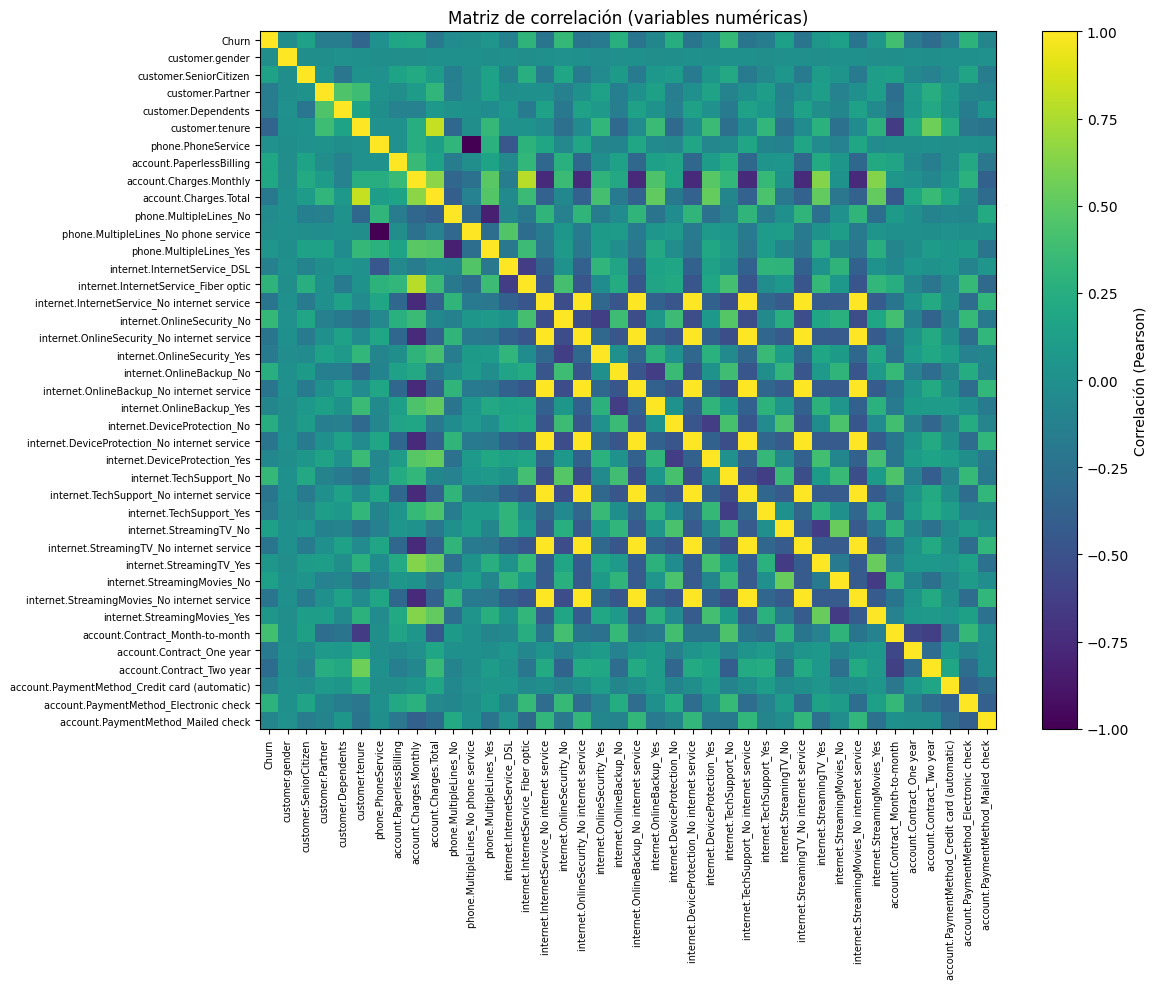

Top correlaciones (abs) con Churn:


,corr_with_Churn
account.Contract_Month-to-month,0.395584
customer.tenure,-0.344079
internet.OnlineSecurity_No,0.335656
internet.TechSupport_No,0.330446
internet.InternetService_Fiber optic,0.300949
account.Contract_Two year,-0.295138
account.PaymentMethod_Electronic check,0.294626
internet.OnlineBackup_No,0.263111
internet.DeviceProtection_No,0.246919
internet.OnlineSecurity_No internet service,-0.224051


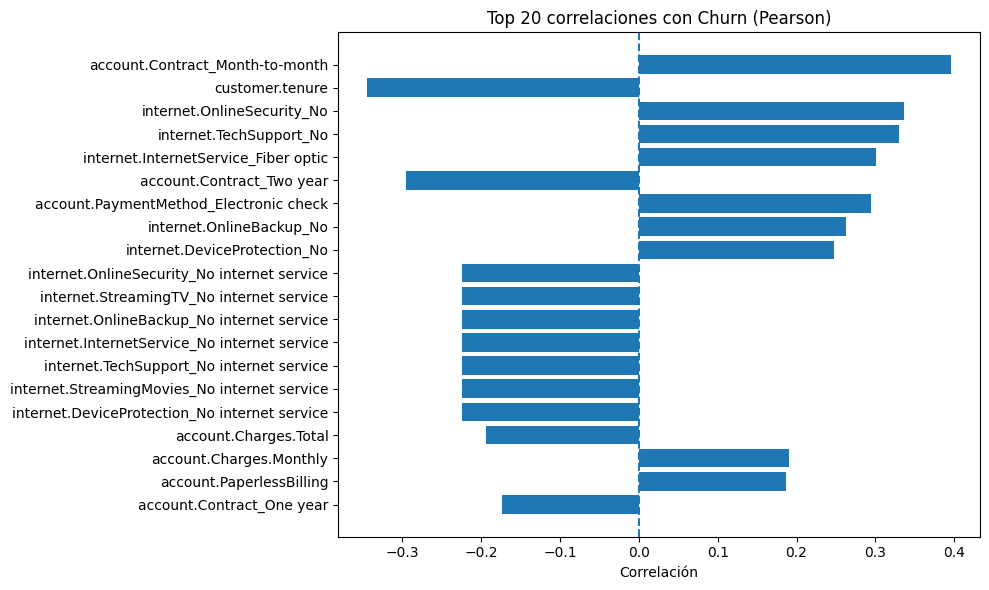

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Seleccionar columnas numéricas (incluye binarias 0/1)
num_df = df.select_dtypes(include=[np.number]).copy()

# Asegura que Churn esté incluido y sea numérico
if "Churn" not in num_df.columns:
    num_df["Churn"] = df["Churn"].astype(int)
else:
    num_df["Churn"] = num_df["Churn"].astype(int)

# 2) Correlación (Pearson por defecto)
corr = num_df.corr(method="pearson")

# 3) Heatmap de correlación (todas las numéricas)
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlación (Pearson)")
plt.title("Matriz de correlación (variables numéricas)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.tight_layout()
plt.show()

# 4) Correlación con Churn (ordenada por valor absoluto)
churn_corr = corr["Churn"].drop("Churn").sort_values(key=lambda s: s.abs(), ascending=False)

print("Top correlaciones (abs) con Churn:")
display(churn_corr.head(20).to_frame(name="corr_with_Churn"))

# 5) Gráfica de barras del Top-N correlacionado con Churn
top_n = 20
top = churn_corr.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top.index[::-1], top.values[::-1])
plt.axvline(0, linestyle="--")
plt.title(f"Top {top_n} correlaciones con Churn (Pearson)")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

In [15]:
corr_spearman = num_df.corr(method="spearman")
churn_corr_s = corr_spearman["Churn"].drop("Churn").sort_values(key=lambda s: s.abs(), ascending=False)
display(churn_corr_s.head(20).to_frame(name="spearman_corr_with_Churn"))

,spearman_corr_with_Churn
account.Contract_Month-to-month,0.395584
customer.tenure,-0.358421
internet.OnlineSecurity_No,0.335656
internet.TechSupport_No,0.330446
internet.InternetService_Fiber optic,0.300949
account.Contract_Two year,-0.295138
account.PaymentMethod_Electronic check,0.294626
internet.OnlineBackup_No,0.263111
internet.DeviceProtection_No,0.246919
account.Charges.Total,-0.225917


/tmp/ipykernel_279/3101422078.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


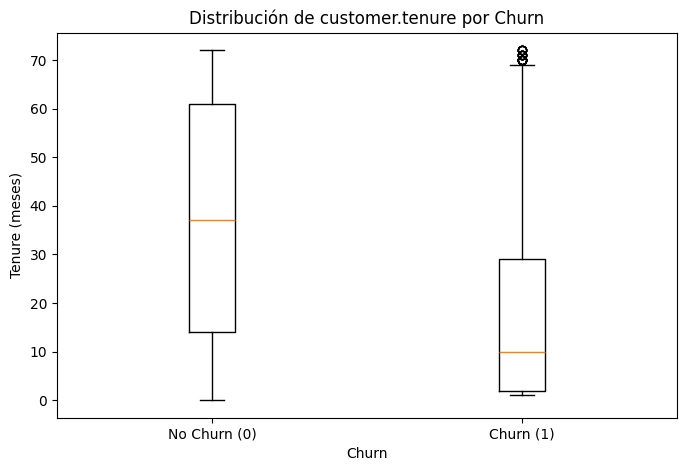

In [16]:
import matplotlib.pyplot as plt

# Separar grupos
tenure_no_churn = df[df["Churn"] == 0]["customer.tenure"]
tenure_churn = df[df["Churn"] == 1]["customer.tenure"]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [tenure_no_churn, tenure_churn],
    labels=["No Churn (0)", "Churn (1)"]
)
plt.title("Distribución de customer.tenure por Churn")
plt.ylabel("Tenure (meses)")
plt.xlabel("Churn")
plt.show()

/tmp/ipykernel_279/4019280733.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


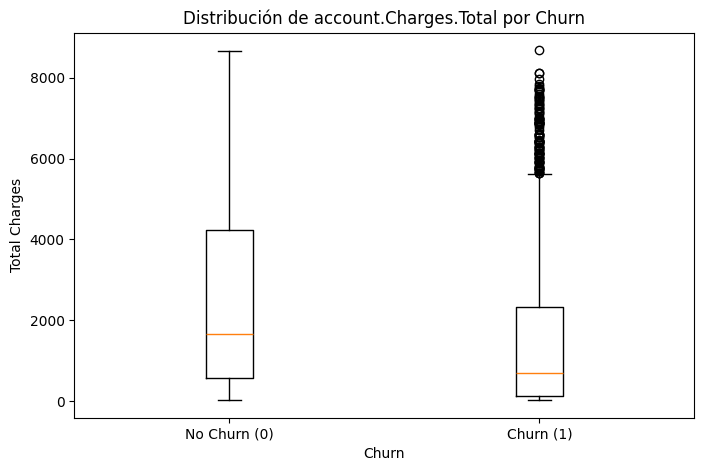

In [17]:
import matplotlib.pyplot as plt

total_no_churn = df[df["Churn"] == 0]["account.Charges.Total"]
total_churn = df[df["Churn"] == 1]["account.Charges.Total"]

plt.figure(figsize=(8, 5))
plt.boxplot(
    [total_no_churn, total_churn],
    labels=["No Churn (0)", "Churn (1)"]
)
plt.title("Distribución de account.Charges.Total por Churn")
plt.ylabel("Total Charges")
plt.xlabel("Churn")
plt.show()

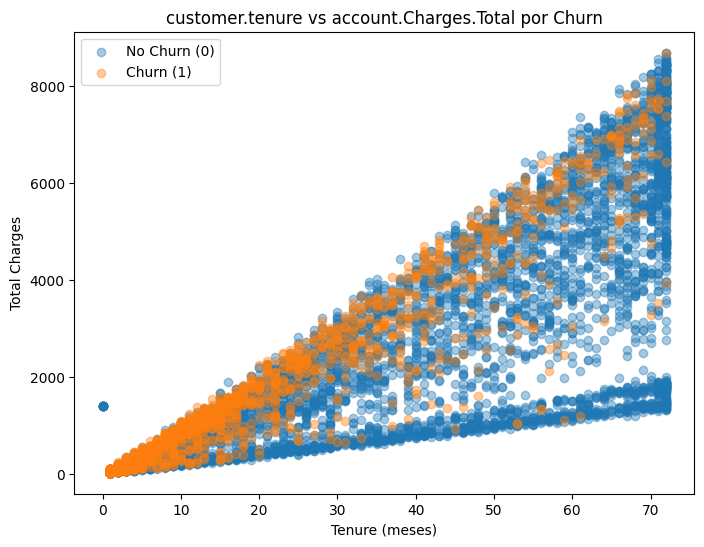

In [18]:
import matplotlib.pyplot as plt

# Separar por clase
df_no_churn = df[df["Churn"] == 0]
df_churn = df[df["Churn"] == 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    df_no_churn["customer.tenure"],
    df_no_churn["account.Charges.Total"],
    alpha=0.4,
    label="No Churn (0)"
)

plt.scatter(
    df_churn["customer.tenure"],
    df_churn["account.Charges.Total"],
    alpha=0.4,
    label="Churn (1)"
)

plt.title("customer.tenure vs account.Charges.Total por Churn")
plt.xlabel("Tenure (meses)")
plt.ylabel("Total Charges")
plt.legend()
plt.show()

In [19]:
df.groupby("Churn")[["customer.tenure", "account.Charges.Total"]].describe()

customer.tenure                                                     \
                count       mean        std  min   25%   50%   75%   max   
Churn                                                                      
0              5398.0  37.321045  24.178367  0.0  14.0  37.0  61.0  72.0   
1              1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      account.Charges.Total                                            \
                      count         mean          std    min      25%   
Churn                                                                   
0                    5398.0  2538.094878  2328.563386  18.80  571.075   
1                    1869.0  1531.796094  1890.822994  18.85  134.500   

                                    
            50%       75%      max  
Churn                               
0      1663.625  4237.275  8672.45  
1       703.550  2331.300  8684.80

#Creación de Modelos

<a name="creacion-de-modelo-knn-baseline"></a>
###Creación de Modelo KNN baseline (sin SMOTE)

=== Classification report (TEST) - KNN baseline ===
              precision    recall  f1-score   support

           0     0.8305    0.8574    0.8437      1080
           1     0.5457    0.4947    0.5189       374

    accuracy                         0.7641      1454
   macro avg     0.6881    0.6760    0.6813      1454
weighted avg     0.7572    0.7641    0.7602      1454

ROC-AUC: 0.7804
PR-AUC (Average Precision): 0.4915


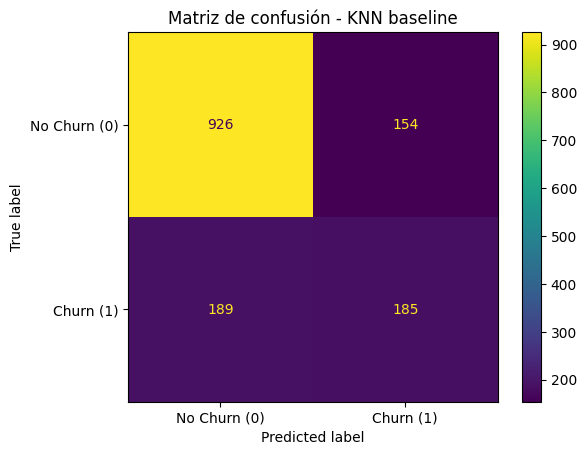

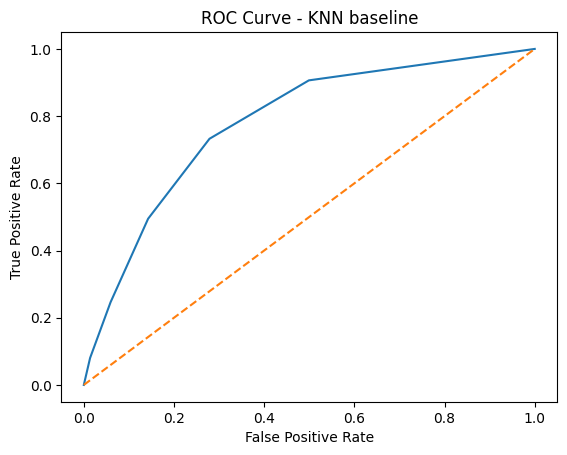

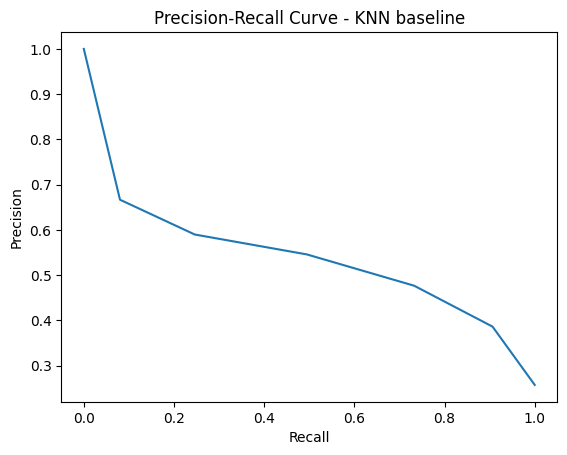

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------- 2) Preprocesamiento ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Modelo KNN baseline ----------
knn_clf = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2
)

knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", knn_clf)
])

knn_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - KNN baseline ===")
print(classification_report(y_test, y_pred_knn, digits=4))

roc_auc_knn = roc_auc_score(y_test, y_proba_knn)
pr_auc_knn = average_precision_score(y_test, y_proba_knn)

print(f"ROC-AUC: {roc_auc_knn:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_knn:.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - KNN baseline")
plt.show()

# Curva ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
plt.figure()
plt.plot(fpr_knn, tpr_knn)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN baseline")
plt.show()

# Curva Precision-Recall
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_proba_knn)
plt.figure()
plt.plot(recall_knn, precision_knn)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - KNN baseline")
plt.show()

<a name="creacion-de-modelo-knn-con-smote"></a>
###Creación de Modelo KNN con SMOTE

=== Classification report (TEST) - KNN + SMOTE ===
              precision    recall  f1-score   support

           0     0.8675    0.7093    0.7804      1080
           1     0.4501    0.6872    0.5439       374

    accuracy                         0.7036      1454
   macro avg     0.6588    0.6982    0.6622      1454
weighted avg     0.7601    0.7036    0.7196      1454

ROC-AUC: 0.7612
PR-AUC (Average Precision): 0.4577


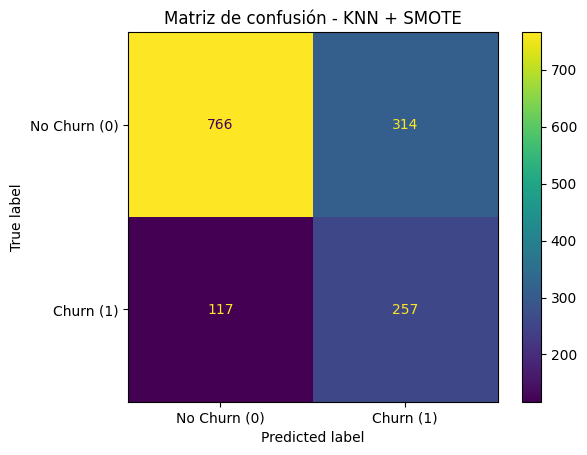

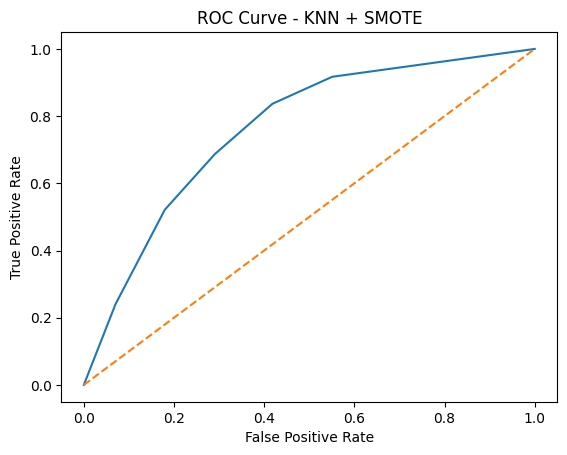

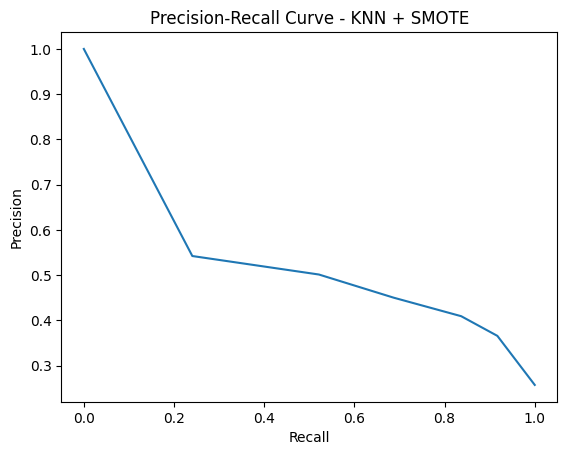

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------- 2) Preprocesamiento ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) SMOTE + KNN ----------
smote = SMOTE(random_state=42, k_neighbors=5)

knn_smote_clf = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2
)

knn_smote_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", smote),
    ("clf", knn_smote_clf)
])

knn_smote_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred_knn_smote = knn_smote_model.predict(X_test)
y_proba_knn_smote = knn_smote_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - KNN + SMOTE ===")
print(classification_report(y_test, y_pred_knn_smote, digits=4))

roc_auc_knn_smote = roc_auc_score(y_test, y_proba_knn_smote)
pr_auc_knn_smote = average_precision_score(y_test, y_proba_knn_smote)

print(f"ROC-AUC: {roc_auc_knn_smote:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_knn_smote:.4f}")

cm_knn_smote = confusion_matrix(y_test, y_pred_knn_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_smote, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - KNN + SMOTE")
plt.show()

# Curva ROC
fpr_knn_smote, tpr_knn_smote, _ = roc_curve(y_test, y_proba_knn_smote)
plt.figure()
plt.plot(fpr_knn_smote, tpr_knn_smote)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN + SMOTE")
plt.show()

# Curva Precision-Recall
precision_knn_smote, recall_knn_smote, _ = precision_recall_curve(y_test, y_proba_knn_smote)
plt.figure()
plt.plot(recall_knn_smote, precision_knn_smote)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - KNN + SMOTE")
plt.show()

<a name="random-forest-baseline"></a>
###Random Forest baseline

=== Classification report (TEST) - Random Forest baseline ===
              precision    recall  f1-score   support

           0     0.8358    0.8861    0.8602      1080
           1     0.6019    0.4973    0.5447       374

    accuracy                         0.7861      1454
   macro avg     0.7189    0.6917    0.7024      1454
weighted avg     0.7757    0.7861    0.7791      1454

ROC-AUC: 0.8230
PR-AUC (Average Precision): 0.5632


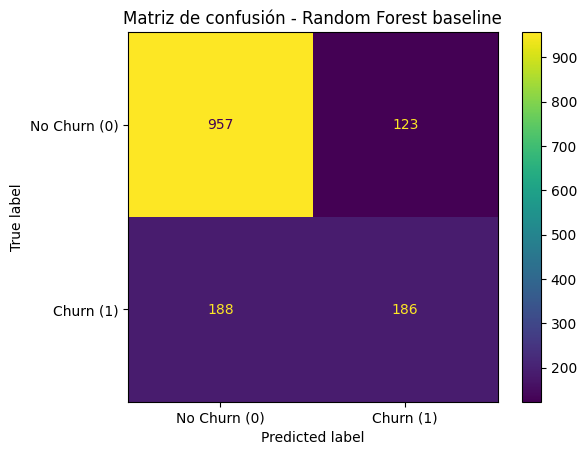

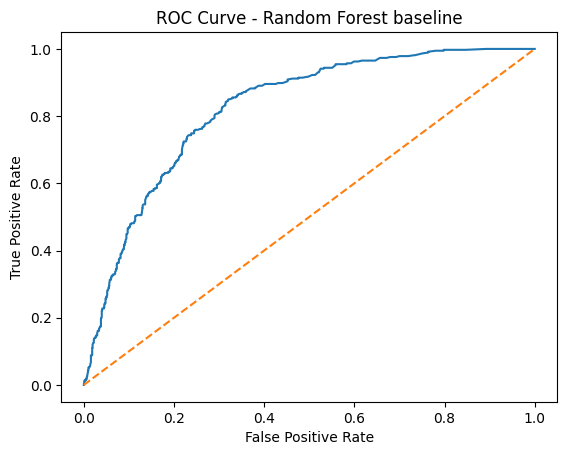

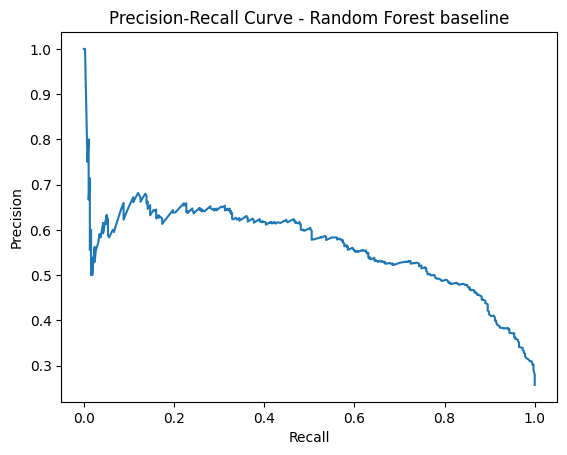

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------- 2) Preprocesamiento ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Modelo Random Forest baseline ----------
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", rf_clf)
])

rf_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - Random Forest baseline ===")
print(classification_report(y_test, y_pred_rf, digits=4))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Random Forest baseline")
plt.show()

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest baseline")
plt.show()

# Curva Precision-Recall
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
plt.figure()
plt.plot(recall_rf, precision_rf)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest baseline")
plt.show()

<a name="random-forest-balanced"></a>
###Random Forest balanceado (class_weight="balanced")

=== Classification report (TEST) - Random Forest class_weight='balanced' ===
              precision    recall  f1-score   support

           0     0.8293    0.8861    0.8568      1080
           1     0.5900    0.4733    0.5252       374

    accuracy                         0.7799      1454
   macro avg     0.7096    0.6797    0.6910      1454
weighted avg     0.7677    0.7799    0.7715      1454

ROC-AUC: 0.8202
PR-AUC (Average Precision): 0.5562


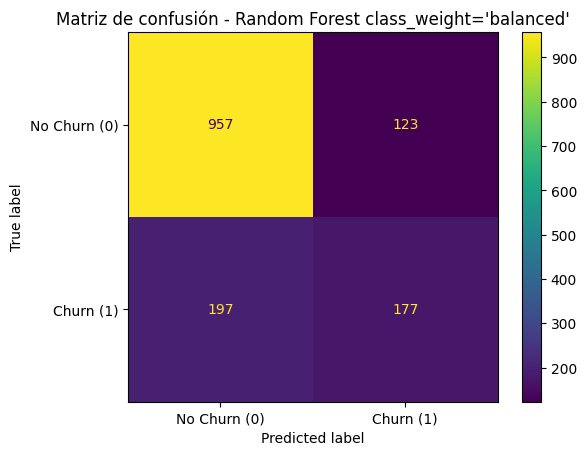

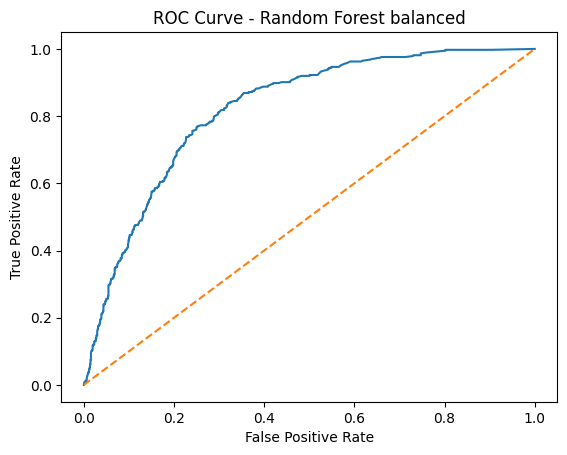

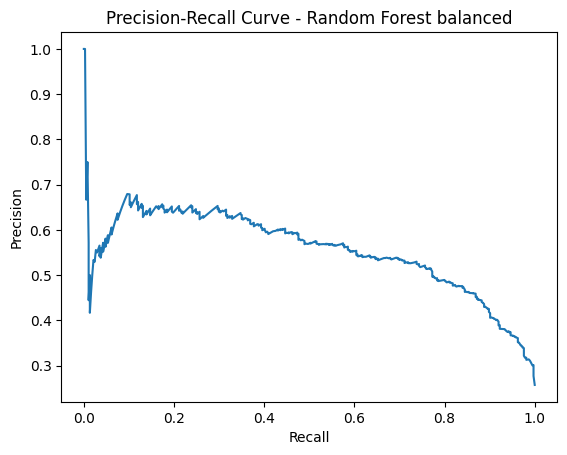

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# ---------- 1) Split estratificado ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------- 2) Preprocesamiento ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Modelo Random Forest balanced ----------
rf_bal_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bal_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", rf_bal_clf)
])

rf_bal_model.fit(X_train, y_train)

# ---------- 4) Evaluación ----------
y_pred_rf_bal = rf_bal_model.predict(X_test)
y_proba_rf_bal = rf_bal_model.predict_proba(X_test)[:, 1]

print("=== Classification report (TEST) - Random Forest class_weight='balanced' ===")
print(classification_report(y_test, y_pred_rf_bal, digits=4))

roc_auc_rf_bal = roc_auc_score(y_test, y_proba_rf_bal)
pr_auc_rf_bal = average_precision_score(y_test, y_proba_rf_bal)

print(f"ROC-AUC: {roc_auc_rf_bal:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_rf_bal:.4f}")

cm_rf_bal = confusion_matrix(y_test, y_pred_rf_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_bal, display_labels=["No Churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Matriz de confusión - Random Forest class_weight='balanced'")
plt.show()

# Curva ROC
fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_proba_rf_bal)
plt.figure()
plt.plot(fpr_rf_bal, tpr_rf_bal)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest balanced")
plt.show()

# Curva Precision-Recall
precision_rf_bal, recall_rf_bal, _ = precision_recall_curve(y_test, y_proba_rf_bal)
plt.figure()
plt.plot(recall_rf_bal, precision_rf_bal)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest balanced")
plt.show()

#Análisis de la Importancia de las Variables

<a name="importancia-variables-random-forest"></a>
###Análisis de la Importancia de las Variables en Random Forest

Top 20 variables más importantes en Random Forest:


,feature,importance
8,num__account.Charges.Total,0.178045
7,num__account.Charges.Monthly,0.154302
4,num__customer.tenure,0.149958
33,num__account.Contract_Month-to-month,0.047273
37,num__account.PaymentMethod_Electronic check,0.030210
24,num__internet.TechSupport_No,0.029698
15,num__internet.OnlineSecurity_No,0.029169
0,num__customer.gender,0.028562
13,num__internet.InternetService_Fiber optic,0.026822
6,num__account.PaperlessBilling,0.024555


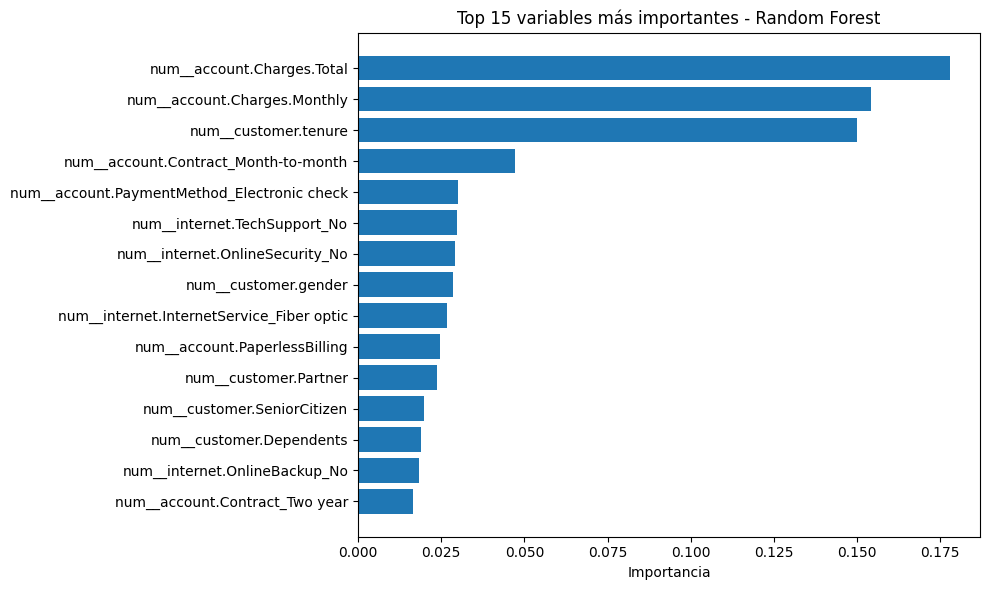

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# ---------- 1) Split ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------- 2) Preprocesamiento ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 3) Random Forest baseline ----------
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# ---------- 4) Extraer feature importances ----------
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["clf"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 20 variables más importantes en Random Forest:")
display(fi_df.head(20))

# ---------- 5) Gráfico ----------
top_n = 15
top_fi = fi_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_fi["feature"][::-1], top_fi["importance"][::-1])
plt.title(f"Top {top_n} variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

<a name="importancia-variables-lr"></a>
###Análisis de la Importancia de las Variables en Linear Regression (Modelo ganador)

In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------- 1) Split ----------
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------- 2) Columnas ----------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

# ---------- 3) Preprocesamiento ----------
numeric_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

# ---------- 4) Modelo ganador ----------
smote = SMOTE(random_state=42, k_neighbors=5)

final_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", smote),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

final_model.fit(X_train, y_train)

# ---------- 5) Obtener nombres de variables transformadas ----------
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

# ---------- 6) Obtener coeficientes ----------
coefs = final_model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
})

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Top 20 variables más influyentes:")
display(coef_df.head(20))

print("Top 10 variables que AUMENTAN churn:")
display(coef_df.sort_values("coefficient", ascending=False).head(10))

print("Top 10 variables que REDUCEN churn:")
display(coef_df.sort_values("coefficient", ascending=True).head(10))

Top 20 variables más influyentes:


,feature,coefficient,abs_coefficient
4,num__customer.tenure,-1.595847,1.595847
7,num__account.Charges.Monthly,-0.919405,0.919405
8,num__account.Charges.Total,0.858497,0.858497
13,num__internet.InternetService_Fiber optic,0.471973,0.471973
33,num__account.Contract_Month-to-month,0.392667,0.392667
35,num__account.Contract_Two year,-0.264617,0.264617
12,num__internet.InternetService_DSL,-0.264574,0.264574
32,num__internet.StreamingMovies_Yes,0.231404,0.231404
29,num__internet.StreamingTV_Yes,0.225538,0.225538
6,num__account.PaperlessBilling,0.222219,0.222219


Top 10 variables que AUMENTAN churn:


,feature,coefficient,abs_coefficient
8,num__account.Charges.Total,0.858497,0.858497
13,num__internet.InternetService_Fiber optic,0.471973,0.471973
33,num__account.Contract_Month-to-month,0.392667,0.392667
32,num__internet.StreamingMovies_Yes,0.231404,0.231404
29,num__internet.StreamingTV_Yes,0.225538,0.225538
6,num__account.PaperlessBilling,0.222219,0.222219
24,num__internet.TechSupport_No,0.181876,0.181876
37,num__account.PaymentMethod_Electronic check,0.176084,0.176084
15,num__internet.OnlineSecurity_No,0.167169,0.167169
23,num__internet.DeviceProtection_Yes,0.161503,0.161503


Top 10 variables que REDUCEN churn:


,feature,coefficient,abs_coefficient
4,num__customer.tenure,-1.595847,1.595847
7,num__account.Charges.Monthly,-0.919405,0.919405
35,num__account.Contract_Two year,-0.264617,0.264617
12,num__internet.InternetService_DSL,-0.264574,0.264574
3,num__customer.Dependents,-0.091715,0.091715
31,num__internet.StreamingMovies_No internet service,-0.057803,0.057803
14,num__internet.InternetService_No internet service,-0.057803,0.057803
28,num__internet.StreamingTV_No internet service,-0.057803,0.057803
19,num__internet.OnlineBackup_No internet service,-0.057803,0.057803
16,num__internet.OnlineSecurity_No internet service,-0.057803,0.057803


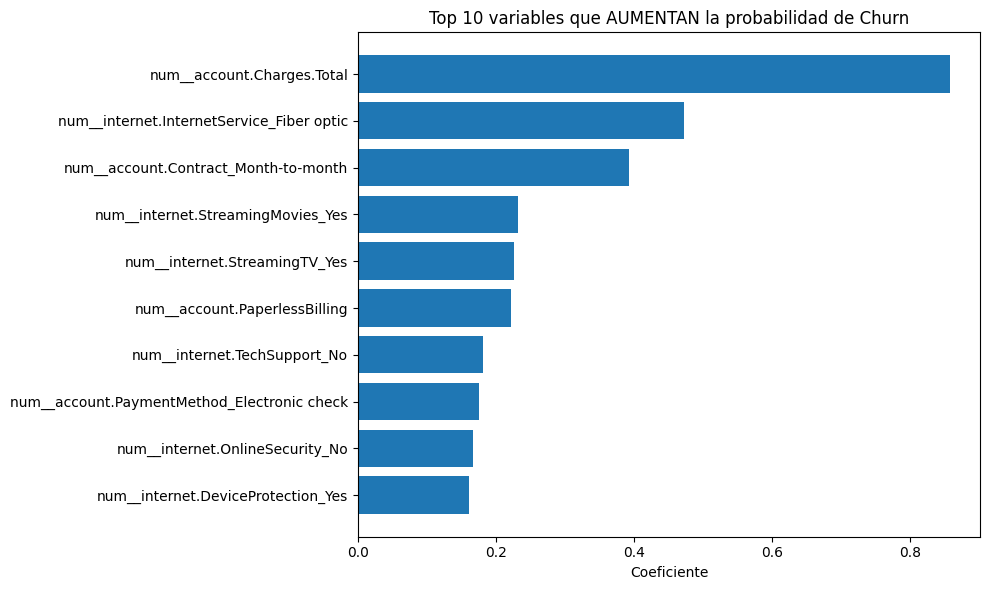

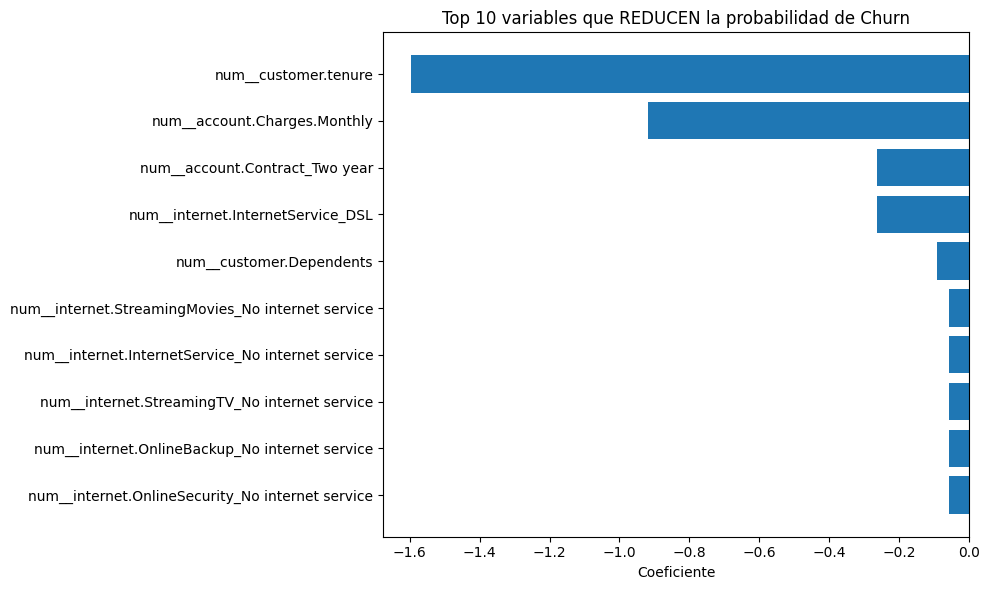

In [26]:
import matplotlib.pyplot as plt

top_pos = coef_df.sort_values("coefficient", ascending=False).head(10)
top_neg = coef_df.sort_values("coefficient", ascending=True).head(10)

# Variables que aumentan churn
plt.figure(figsize=(10, 6))
plt.barh(top_pos["feature"][::-1], top_pos["coefficient"][::-1])
plt.title("Top 10 variables que AUMENTAN la probabilidad de Churn")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

# Variables que reducen churn
plt.figure(figsize=(10, 6))
plt.barh(top_neg["feature"][::-1], top_neg["coefficient"][::-1])
plt.title("Top 10 variables que REDUCEN la probabilidad de Churn")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

#Comparación del modelo ganador de los segmentos TRAIN vs TEST para revisar OVERFITTING y UNDERFITTING.

<a name="overfitting-underfitting-sin-crossvalidate"></a>
###Comparación del modelo ganador de los segmentos TRAIN vs TEST para revisar OVERFITTING y UNDERFITTING.

In [27]:
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score

# ===== TRAIN =====
y_train_pred = final_model.predict(X_train)
y_train_proba = final_model.predict_proba(X_train)[:, 1]

print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred, digits=4))
print("ROC-AUC (train):", round(roc_auc_score(y_train, y_train_proba), 4))
print("PR-AUC  (train):", round(average_precision_score(y_train, y_train_proba), 4))

# ===== TEST =====
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== TEST ===")
print(classification_report(y_test, y_test_pred, digits=4))
print("ROC-AUC (test):", round(roc_auc_score(y_test, y_test_proba), 4))
print("PR-AUC  (test):", round(average_precision_score(y_test, y_test_proba), 4))

=== TRAIN ===
              precision    recall  f1-score   support

           0     0.9133    0.7341    0.8140      4318
           1     0.5098    0.7987    0.6224      1495

    accuracy                         0.7507      5813
   macro avg     0.7116    0.7664    0.7182      5813
weighted avg     0.8095    0.7507    0.7647      5813

ROC-AUC (train): 0.8433
PR-AUC  (train): 0.6415

=== TEST ===
              precision    recall  f1-score   support

           0     0.9166    0.7426    0.8205      1080
           1     0.5199    0.8048    0.6317       374

    accuracy                         0.7586      1454
   macro avg     0.7182    0.7737    0.7261      1454
weighted avg     0.8145    0.7586    0.7719      1454

ROC-AUC (test): 0.8432
PR-AUC  (test): 0.625


#Comparación del modelo ganador de los segmentos TRAIN vs TEST para revisar OVERFITTING y UNDERFITTING usando CROSS VALIDATE.

<a name="overfitting-underfitting"></a>
###Comparación del modelo ganador de los segmentos TRAIN vs TEST para revisar OVERFITTING y UNDERFITTING usando CROSS VALIDATE.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "ap": "average_precision"
}

cv_results = cross_validate(
    final_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

for metric in scoring.keys():
    train_mean = cv_results[f"train_{metric}"].mean()
    test_mean = cv_results[f"test_{metric}"].mean()
    print(f"{metric.upper()} -> train: {train_mean:.4f} | test: {test_mean:.4f}")

F1 -> train: 0.6208 | test: 0.6150
RECALL -> train: 0.7971 | test: 0.7892
ROC_AUC -> train: 0.8436 | test: 0.8399
AP -> train: 0.6385 | test: 0.6316


<a name="resumen-numerologia-modelos"></a>
###Resúmen de numerología de modelos

In [29]:
import pandas as pd

results = pd.DataFrame([
    {
        "Modelo": "Logistic Regression baseline",
        "TP": 201, "FP": 117, "FN": 173, "TN": 963,
        "Recall(1)": 0.5374,
        "Precision(1)": 0.6321,
        "F1(1)": 0.5809,
        "ROC-AUC": 0.8439,
        "PR-AUC": 0.6239,
        "Accuracy": 0.8006
    },
    {
        "Modelo": "Logistic Regression class_weight=balanced",
        "TP": 303, "FP": 301, "FN": 71, "TN": 779,
        "Recall(1)": 0.8102,
        "Precision(1)": 0.5017,
        "F1(1)": 0.6196,
        "ROC-AUC": 0.8438,
        "PR-AUC": 0.6214,
        "Accuracy": 0.7442
    },
    {
        "Modelo": "Logistic Regression + SMOTE",
        "TP": 301, "FP": 278, "FN": 73, "TN": 802,
        "Recall(1)": 0.8048,
        "Precision(1)": 0.5199,
        "F1(1)": 0.6317,
        "ROC-AUC": 0.8432,
        "PR-AUC": 0.6250,
        "Accuracy": 0.7586
    },
    {
        "Modelo": "KNN baseline",
        "TP": 185, "FP": 154, "FN": 189, "TN": 926,
        "Recall(1)": 0.4947,
        "Precision(1)": 0.5457,
        "F1(1)": 0.5189,
        "ROC-AUC": 0.7804,
        "PR-AUC": 0.4915,
        "Accuracy": 0.7641
    },
    {
        "Modelo": "KNN + SMOTE",
        "TP": 257, "FP": 314, "FN": 117, "TN": 766,
        "Recall(1)": 0.6872,
        "Precision(1)": 0.4501,
        "F1(1)": 0.5439,
        "ROC-AUC": 0.7612,
        "PR-AUC": 0.4577,
        "Accuracy": 0.7036
    },
    {
        "Modelo": "Random Forest baseline",
        "TP": 186, "FP": 123, "FN": 188, "TN": 957,
        "Recall(1)": 0.4973,
        "Precision(1)": 0.6019,
        "F1(1)": 0.5447,
        "ROC-AUC": 0.8230,
        "PR-AUC": 0.5632,
        "Accuracy": 0.7861
    },
    {
        "Modelo": "Random Forest class_weight=balanced",
        "TP": 177, "FP": 123, "FN": 197, "TN": 957,
        "Recall(1)": 0.4733,
        "Precision(1)": 0.5900,
        "F1(1)": 0.5252,
        "ROC-AUC": 0.8202,
        "PR-AUC": 0.5562,
        "Accuracy": 0.7799
    }
])

display(results.sort_values(by=["F1(1)", "FN"], ascending=[False, True]))

,Modelo,TP,FP,FN,TN,Recall(1),Precision(1),F1(1),ROC-AUC,PR-AUC,Accuracy
2,Logistic Regression + SMOTE,301,278,73,802,0.8048,0.5199,0.6317,0.8432,0.6250,0.7586
1,Logistic Regression class_weight=balanced,303,301,71,779,0.8102,0.5017,0.6196,0.8438,0.6214,0.7442
0,Logistic Regression baseline,201,117,173,963,0.5374,0.6321,0.5809,0.8439,0.6239,0.8006
5,Random Forest baseline,186,123,188,957,0.4973,0.6019,0.5447,0.8230,0.5632,0.7861
4,KNN + SMOTE,257,314,117,766,0.6872,0.4501,0.5439,0.7612,0.4577,0.7036
6,Random Forest class_weight=balanced,177,123,197,957,0.4733,0.5900,0.5252,0.8202,0.5562,0.7799
3,KNN baseline,185,154,189,926,0.4947,0.5457,0.5189,0.7804,0.4915,0.7641


###**Informe Técnico.**
###**TelecomX** es una compañía de servicios de telecomunicación que ofrece diversos servicios a clientes tanto de telefonía, Internet, Soporte Técnico, así como de entretenimiento. Se nos ha buscado como analistas de datos para hacer un análisis del estado actual del servicio en general.
###El objetivo del análisis es apoyar a la empresa **TelecomX** a minimizar a través de un análisis de datos la evasión de clientes (Churn) en la compañía debido a factores que ignora de momento y al mismo tiempo fortalecer el servicio a través del descubrimiento que ofrece la Ciencia de Datos sobre los hallazgos que influyan en la percepción del cliente de los servicios que ofrece **TelecomX** con el objetivo final de la mejora contínua.
<!--
LLM Prompt
A manera de adelantar el trabajo, hasta este momento, hemos analizado y limpiado los datos de acuerdo a las buenas prácticas de Ciencia de Datos, sin embargo tu eres un experto en Ciencia de Datos y puedes opcionalmente revisar el avance.

Se te provee el archivo donde esto se refleja y ahora quiero revisar contigo el análisis de los posibles hallazgos que se pueden encontrar para concluir con éxito uno de los objetivos iniciales que es apoyar a TelecomX a disminuir o atacar el 'Churn'.

Sin embargo hay una nueva misión final donde el objetivo es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios. La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

En resumen, los objetivos del desafío incluyen:
1. Preparar los datos para el modelado (tratamiento, codificación, normalización).
2. Realizar análisis de correlación y selección de variables.
3. Entrenar dos o más modelos de clasificación.
4. Evaluar el rendimiento de los modelos con métricas.
5. Interpretar los resultados, incluyendo la importancia de las variables.
6. Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

Como lo puedes ver ahora, los temas involucran Machine Learning para apoyar a concretar los objetivos. Te pido que revises el archivo inicial y que no inicies ningún análisis hasta que yo te lo pida.
-->

###**Extracción del Archivo Tratado.**
###Para comenzar el análisis se parte desde el punto donde en el **Challenge TelecomX Parte I** se concluye con un archivo en donde los datos han sido analizados, limpiados y normalizados de acuerdo a las buenas prácticas de Ciencia de Datos y ahora hay un [archivo de donde partiremos para esta segunda parte del desafío](#extraccion-del-archivo-tratado).

###**Normalización o Estandarización.**

###Debido a que se utilizaron modelos sensibles a la escala de los datos (**Logistic Regression**), las variables numéricas fueron [estandarizadas](#normalización-o-estandarizacion) mediante **StandardScaler**, asegurando media cero y desviación estándar unitaria. Este proceso se implementó dentro de un **Pipeline** para evitar data leakage, garantizando que los parámetros de escalado se estimaran únicamente sobre el conjunto de entrenamiento.
###Como ejemplo, véase el código para ejecutar el [Baseline de regresión lineal sin balanceo](#baseline-reproducible-sin-balanceo)

###**Creación de Modelos.**
###Se compararon distintos enfoques predictivos para la cancelación de clientes, incluyendo Regresión Logística ([baseline](#baseline-reproducible-sin-balanceo), [balanced](#baseline-reproducible-con-balanceo), [SMOTE](#baseline-reproducible-con-smote)), KNN ([con](#creacion-de-modelo-knn-con-smote) y [sin](#creacion-de-modelo-knn-baseline) SMOTE) y Random Forest ([baseline](#random-forest-baseline), [balanced](#random-forest-balanced)). Entre ellos, la [Regresión Logística con balanceo mediante SMOTE](#baseline-reproducible-con-smote) obtuvo el mejor desempeño global bajo el criterio combinado de maximizar el F1-score de la clase churn y minimizar los falsos negativos. Este modelo logró un equilibrio superior entre sensibilidad (recall) y precisión, detectando la mayor proporción de clientes en riesgo sin deteriorar excesivamente la calidad de las predicciones.

###**Evaluación de los Modelos.**
###Considerando como primera parte de esta sección lo visto en **Creación de Modelos**, se evalúo un método canónico donde la [base fue la Regresión Logística](#baseline-reproducible-sin-balanceo) por ser muy efectivo para el tratamiento de la evasión (churn). Posteriormente, el mismo modelo fue [balanceado](#baseline-reproducible-con-balanceo) introduciendo la *class_weight="balanced"* para terminar usando [SMOTE](#baseline-reproducible-con-smote) y revisar el mejor modelo de estas tres primeras etapas canónicas.
###Como segunda parte se evaluó un modelo K-Nearest Neighbors (KNN) como alternativa a la Regresión Logística, considerando que KNN requiere variables escaladas debido a su dependencia de métricas de distancia. Aunque el uso de SMOTE permitió mejorar la sensibilidad (recall) del modelo respecto a la clase churn, el desempeño general de [KNN](#creacion-de-modelo-knn-con-smote) permaneció por debajo del obtenido con Regresión Logística, especialmente en recall, F1-score de la clase positiva, PR-AUC y número de churn detectados. Esto sugiere que, para este dataset, la estructura del problema es mejor capturada por modelos lineales balanceados que por un enfoque basado en proximidad.
###Como última parte de evalúo tambien un modelo [Random Forest](#random-forest-balanced) con estadísticos debajo de los modelos canónicos iniciales.
###El modelo final ganador fue el de Regresión Logística con SMOTE que no mostró señales relevantes de [sobreajuste](#overfitting-underfitting) (overfitting), ya que las métricas obtenidas en entrenamiento y prueba fueron muy similares. Esta estabilidad también fue confirmada mediante validación cruzada estratificada, donde las diferencias entre desempeño en entrenamiento y validación fueron mínimas. En consecuencia, el modelo presenta una capacidad de generalización adecuada sobre datos no vistos.
###Tampoco se observaron señales de [underfitting](#overfitting-underfitting) severo, dado que el modelo alcanzó niveles consistentes y razonables de recall, F1-score y ROC-AUC, especialmente en la detección de la clase churn.
###El modelo final de Regresión Logística con SMOTE confirmó que la cancelación en TelecomX está fuertemente asociada con clientes de baja antigüedad, contratos mes a mes, ausencia de servicios de soporte técnico y seguridad en línea, uso de fibra óptica y método de pago por cheque electrónico. En contraste, una mayor permanencia, los contratos de dos años y ciertas características de estabilidad del cliente, como tener dependientes, se relacionaron con una menor probabilidad de cancelación.
###Algunas variables de facturación, como los cargos mensuales y los cargos totales acumulados, deben interpretarse con cautela debido a su relación estrecha con la antigüedad del cliente y a posibles efectos de colinealidad dentro del modelo.
###Se [resume un estadístico](#resumen-numerologia-modelos) con los números finales de los modelos evaluados.

###**Correlación.**
###El [análisis de correlación](#analisis-de-correlacion) mostró que las variables más asociadas con la cancelación de clientes fueron el contrato mes a mes, la ausencia de servicios adicionales como seguridad en línea y soporte técnico, el uso de fibra óptica y el método de pago por cheque electrónico. En contraste, una mayor antigüedad del cliente, mayores cargos totales acumulados y los contratos de largo plazo se asociaron con una menor probabilidad de churn. Estos hallazgos sugieren que la estabilidad contractual, la permanencia histórica y una mayor integración en el ecosistema de servicios de **TelecomX** son factores protectores frente a la cancelación.
###El riesgo de cancelación es significativamente mayor durante los primeros meses de relación con la empresa. Los clientes que permanecen más tiempo tienden a acumular mayor gasto total y muestran una probabilidad considerablemente menor de cancelar el servicio.

###**Análisis de la Importancia de las Variables.**
###La interpretabilidad del modelo se abordó de acuerdo con la naturaleza de cada algoritmo evaluado. En el caso de la [Regresión Logística](#importancia-variables-lr), se analizaron los coeficientes del modelo para identificar las variables que aumentan o reducen la probabilidad de cancelación. Para KNN, dado que no genera importancias de variables de forma nativa, su interpretación se centró en el papel de la distancia entre observaciones y en la necesidad de estandarizar las variables. En el caso de [Random Forest](#importancia-variables-random-forest), la relevancia de las variables puede analizarse mediante la importancia derivada de la reducción de impureza en los árboles, lo cual ofrece una referencia complementaria sobre los factores más influyentes.

###**Conclusión.**
###Se construyó un benchmark de modelos predictivos para estimar la cancelación de clientes en TelecomX, incluyendo Regresión Logística, KNN y Random Forest, con diferentes estrategias de tratamiento del desbalance como class_weight y SMOTE. Bajo el criterio combinado de maximizar el F1-score de la clase churn y minimizar los falsos negativos, el mejor desempeño fue obtenido por la Regresión Logística con SMOTE, la cual logró el mejor equilibrio entre sensibilidad (recall) y precisión para detectar clientes en riesgo. Este resultado indica que el problema de churn en TelecomX puede modelarse eficazmente mediante un enfoque lineal correctamente preprocesado, balanceado y validado sin fuga de información.
###El análisis exploratorio y de correlación mostró que la cancelación está fuertemente asociada con contratos mes a mes, baja antigüedad del cliente, ausencia de servicios complementarios como seguridad en línea y soporte técnico, uso de fibra óptica y método de pago por cheque electrónico. En contraste, una mayor permanencia, mayores cargos acumulados y contratos de largo plazo se relacionan con una menor probabilidad de cancelación.
###Los clientes que cancelan presentan una antigüedad considerablemente menor que aquellos que permanecen, lo cual sugiere que el riesgo de cancelación es mayor durante las primeras etapas de la relación comercial.
###Los clientes con churn tienden a mostrar menores cargos totales acumulados, lo que es consistente con una menor permanencia y con una vinculación más débil con la empresa.
###La combinación de baja antigüedad y bajo gasto total parece caracterizar una zona de mayor riesgo de cancelación, lo que sugiere una ventana temprana de intervención para estrategias de retención.
###Los resultados sugieren que TelecomX debería enfocar sus esfuerzos de retención principalmente en clientes con contratos mes a mes, baja antigüedad y baja adopción de servicios complementarios como soporte técnico y seguridad en línea. Asimismo, los clientes de fibra óptica y aquellos que pagan mediante cheque electrónico representan segmentos de mayor riesgo que ameritan monitoreo prioritario. Estratégicamente, la empresa podría reducir la cancelación mediante programas de fidelización temprana, incentivos para migrar a contratos de largo plazo, promoción de add-ons de soporte y seguridad, y optimización de la experiencia de clientes de fibra óptica.

###**Informe Final.**
###**Predicción y Análisis de Cancelación de Clientes (Churn).**
###**TelecomX LATAM.**

---


###**1.   Introducción**

###La cancelación de clientes (churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que implica la pérdida directa de ingresos y mayores costos de adquisición de nuevos clientes.

###TelecomX LATAM ofrece diversos servicios de telecomunicaciones, incluyendo telefonía, internet, soporte técnico y servicios de entretenimiento. La empresa ha identificado la necesidad de comprender los factores que influyen en la cancelación de clientes y desarrollar herramientas predictivas que permitan anticiparse a este fenómeno.

###El objetivo principal de este proyecto es utilizar técnicas de **Ciencia de Datos y Machine Learning** para:

*   Identificar los factores asociados a la cancelación de clientes.
*   Construir modelos predictivos capaces de estimar la probabilidad de churn.
*   Proporcionar recomendaciones estratégicas para reducir la evasión de clientes.



---

###**2. Metodología**

###El proyecto se desarrolló siguiendo una metodología estándar de Ciencia de Datos, que incluye:

###**1.   Preparación y limpieza de datos**
###**2.   Análisis exploratorio**
###**3.   Ingeniería de variables**
###**4.   Construcción de modelos predictivos**
###**5.   Evaluación y comparación de modelos**
###**6.   Interpretación de variables relevantes**
###**7.   Conclusiones estratégicas**






---
###**3. Preparación de los datos**

###Antes de construir los modelos predictivos se realizaron varias etapas de preprocesamiento para asegurar la calidad y consistencia de los datos.

###**Limpieza y tratamiento de datos**

###Las principales acciones incluyeron:

###Eliminación de columnas irrelevantes para el análisis.

###Conversión de variables categóricas mediante **One-Hot Encoding**.

###Tratamiento de valores faltantes mediante imputación (uso de la mediana, en el caso de datos numéricos, realizado en la Parte I del Challenge y reforzado aquí).

###Estandarización de variables numéricas cuando el modelo lo requería.

###**Separación de datos**

###El conjunto de datos fue dividido en:

###**80% entrenamiento**

###**20% prueba**

###**utilizando estratificación por la variable Churn**, con el objetivo de mantener la proporción original de cancelaciones en ambos conjuntos.

###Esto permitió evitar sesgos durante el entrenamiento y evaluar correctamente la capacidad de generalización de los modelos.




---
###**4. Análisis exploratorio de datos**

###Se realizó un análisis exploratorio para identificar patrones iniciales relacionados con la cancelación.

###Entre los hallazgos más relevantes se encontraron:

###**Variables asociadas positivamente con el churn**

*   Contratos mes a mes
*   Falta de servicios adicionales como:

    *   soporte técnico
    *   seguridad en línea

*  Uso de fibra óptica
*  Método de pago electronic check

###**Variables asociadas negativamente con el churn**
*  Mayor antigüedad del cliente (tenure)
*  Contratos de largo plazo
*  Mayor estabilidad del cliente (ej. clientes con dependientes)

###Estos hallazgos fueron posteriormente confirmados por los modelos predictivos.




---
###**5. Modelos predictivos evaluados**

###Para estimar la probabilidad de cancelación se evaluaron diferentes algoritmos de clasificación.

###Los modelos utilizados fueron:

*  **Regresión Logística**
*  **K-Nearest Neighbors (KNN)**
*  **Random Forest**

###Además, se aplicaron distintas estrategias para tratar el desbalance en la variable objetivo, incluyendo:

*  modelo baseline
*  *class_weight="balanced"*
*  **SMOTE (Synthetic Minority Oversampling Technique)**




---
###**6. Comparación de modelos**

###Se evaluaron los modelos utilizando métricas relevantes para problemas de churn, principalmente:

*  **Recall de la clase churn**

*  **F1-score de la clase churn**

*  **ROC-AUC**

*  **PR-AUC**

*  **número de falsos negativos (FN en Matriz de Confusión)**

###Los resultados comparativos mostraron que el modelo con mejor desempeño fue:

###**Regresión Logística + SMOTE**

###Este modelo logró el mejor equilibrio entre sensibilidad (recall) y precisión en la detección de clientes en riesgo.

###Principales resultados del modelo ganador

| Métrica          | Valor |
| ---------------- | ----- |
| Recall (Churn)   | ~0.80 |
| F1-score (Churn) | ~0.63 |
| ROC-AUC          | ~0.84 |
| PR-AUC           | ~0.62 |
| FN               | 73 |

###Estos resultados indican una buena capacidad del modelo para identificar clientes con alta probabilidad de cancelación.




---
###**7. Validación del modelo**

###Para evaluar la estabilidad del modelo se analizaron:

* **desempeño en train vs test**

* **validación cruzada**

###Los resultados fueron consistentes:

| Métrica | Train  | Test   |
| ------- | ------ | ------ |
| F1      | 0.6208 | 0.6150 |
| Recall  | 0.7971 | 0.7892 |
| ROC-AUC | 0.8436 | 0.8399 |


##La pequeña diferencia entre entrenamiento y prueba indica que el modelo:

* **no presenta sobreajuste significativo**

* generaliza adecuadamente a datos no vistos




---
###**8. Interpretación de variables relevantes**

###Para entender qué factores influyen en la cancelación se analizaron:

* **coeficientes de la Regresión Logística**

* **importancia de variables en Random Forest**

###**Variables que aumentan la probabilidad de churn**

##Entre los factores más influyentes se encontraron:

* Contrato **Month-to-month**

* Servicio de **fibra óptica**

* Falta de **soporte técnico**

* Falta de **seguridad en línea**

* Método de pago **electronic check**

* Uso de **servicios de streaming**


---
###**Variables que reducen la probabilidad de churn**

###Los factores que más contribuyen a la retención incluyen:

* Mayor **antigüedad del cliente**

* Contratos de **dos años**

* Presencia de **dependientes**

* Algunos tipos de servicio más estables (por ejemplo DSL)

###En particular, la antigüedad del cliente fue el predictor más fuerte de permanencia.





---
###**9. Recomendaciones estratégicas para TelecomX**

###Con base en el análisis realizado, se proponen las siguientes acciones estratégicas:

####**1. Fortalecer la retención en los primeros meses**

####Los clientes con menor antigüedad presentan mayor riesgo de cancelación.
####Se recomienda implementar programas de fidelización temprana durante los primeros meses del cliente.

---

####**2. Incentivar contratos de largo plazo**

####Los contratos de dos años muestran una fuerte relación con la retención.

####Se podrían ofrecer:

* descuentos por permanencia
* beneficios exclusivos por contrato extendido

---
####**3. Promover servicios adicionales**

####Los clientes que utilizan add-ons como:

* soporte técnico
* seguridad en línea

####presentan menor probabilidad de cancelación.

####Promover estos servicios puede aumentar la fidelidad del cliente.

---

####**4. Analizar el segmento de fibra óptica**

####Los clientes con fibra óptica muestran mayor propensión al churn.

####Esto podría indicar:

* mayor sensibilidad al precio
* mayor competencia
* mayores expectativas de calidad

####Se recomienda analizar la experiencia de este segmento con mayor detalle.

---
####**5. Optimizar métodos de pago**

####El método electronic check aparece asociado a mayor churn.

####Se podría incentivar el uso de:

* pagos automáticos
* tarjetas o débito automático

####para mejorar la retención.




---
###**10. Conclusión**

###Este proyecto demostró que las técnicas de Ciencia de Datos pueden proporcionar información valiosa para comprender y predecir la cancelación de clientes en **TelecomX**.

###Entre los modelos evaluados, la Regresión Logística con SMOTE mostró el mejor desempeño para identificar clientes en riesgo de abandono.

###El análisis permitió identificar factores clave asociados con el churn, incluyendo el tipo de contrato, la antigüedad del cliente, el uso de servicios complementarios y ciertos métodos de pago.

###Estos hallazgos pueden ayudar a **TelecomX** a diseñar estrategias más efectivas de retención de clientes, reducir la tasa de cancelación y mejorar la estabilidad de sus ingresos.
